<a href="https://colab.research.google.com/github/Karthik5412/100-pandas-puzzles/blob/master/dl_notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive

drive.mount('/content/drive/')


Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


In [2]:
import zipfile
from pathlib import Path
extract_path = Path("/content/extracted_data")

with zipfile.ZipFile('/content/drive/MyDrive/Deep_Learning/custumes/archive (23).zip', 'r') as ref:
    ref.extractall('extracted_data')

In [3]:
from tensorflow.keras.utils import image_dataset_from_directory

train_ds = image_dataset_from_directory('/content/extracted_data/clothing-dataset-small/train',labels='inferred',label_mode='int', color_mode='rgb', seed=123,image_size=(224,224), batch_size=32)

test_ds = image_dataset_from_directory('/content/extracted_data/clothing-dataset-small/test',labels='inferred',label_mode='int', color_mode='rgb', seed=123,image_size=(224,224), batch_size=32)

Found 3068 files belonging to 10 classes.
Found 372 files belonging to 10 classes.


In [4]:
import pandas as pd
import numpy as np

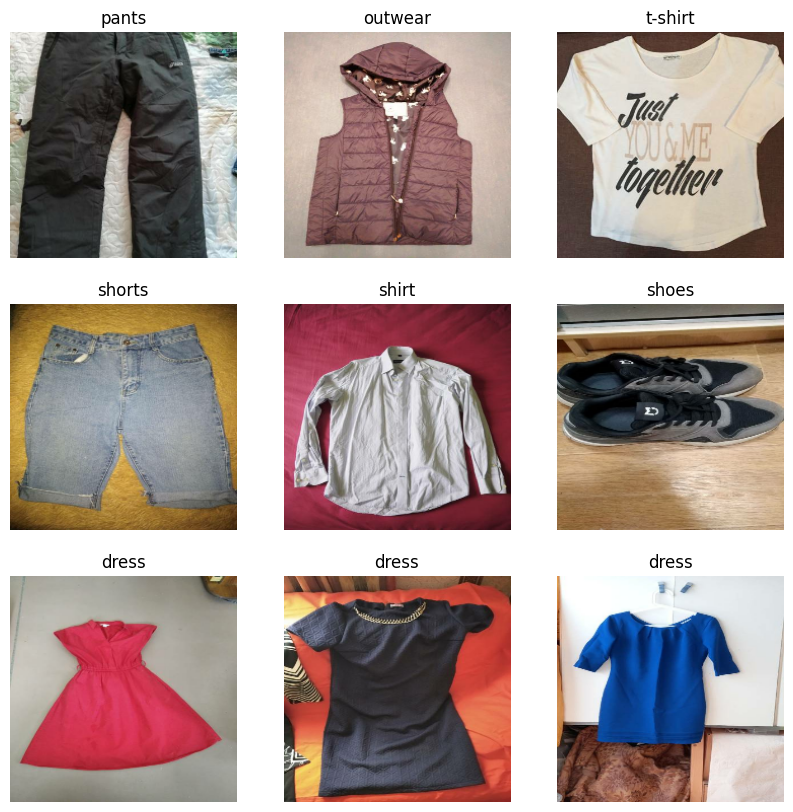

In [5]:
import matplotlib.pyplot as plt

class_names = train_ds.class_names
plt.figure(figsize=(10,10))

for img,label in train_ds.take(1):
    for i in range(0,9):
        plt.subplot(3,3,i+1)

        plt.imshow(img[i].numpy().astype('uint8'))
        plt.title(class_names[label[i]])
        plt.axis('off')





In [6]:
from tensorflow.keras import layers
from tensorflow.keras import Sequential

aug = Sequential([
    layers.RandomRotation(0.05, input_shape=(224,224,3),fill_mode='nearest'),
    layers.RandomFlip('horizontal'),
    layers.RandomZoom(0.1)
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


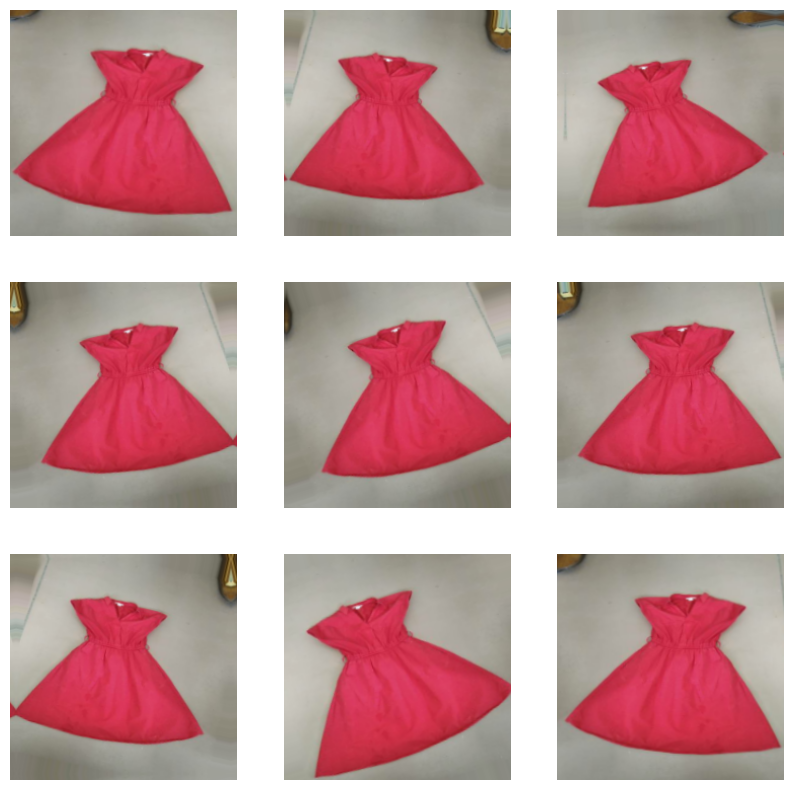

In [7]:
import tensorflow as tf
import matplotlib.pyplot as plt

plt.figure(figsize=(10,10))

for img,labels in train_ds.take(1):

    for i in range(9):
        agumented = aug(img)
        plt.subplot(3,3,i+1)
        plt.imshow(agumented[4].numpy().astype('uint8'))
        plt.axis('off')

In [8]:
from tensorflow.keras.layers import Conv2D, MaxPool2D, GlobalAveragePooling2D, Dense, Dropout, Flatten
from tensorflow.keras import Sequential

In [16]:
cnn = Sequential([
    aug,
    Conv2D(32,kernel_size=(3,3),activation='relu',padding='same'),
    MaxPool2D(2,2),
    Conv2D(64,kernel_size=(3,3),activation='relu',padding='same'),
    MaxPool2D(2,2),
    Conv2D(128,kernel_size=(3,3),activation='relu',padding='same'),
    MaxPool2D(2,2),
    Conv2D(256,kernel_size=(3,3),activation='relu',padding='same'),
    MaxPool2D(2,2),
    Flatten(),
    Dense(256,activation='relu'),
    Dropout(0.5),
    Dense(128,activation='relu'),
    Dropout(0.3),
    Dense(10,activation='softmax'),
])

In [17]:
from tensorflow.keras.optimizers import Adam
ado = Adam(learning_rate=0.002)
cnn.compile(optimizer=ado,loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [18]:
cnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    12,845,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,267,914 (50.61 MB)

 Trainable params: 13,267,914 (50.61 MB)

 Non-trainable params: 0 (0.00 B)

In [19]:
cnn.fit(train_ds,batch_size=32,epochs=75,verbose=1,shuffle=True,validation_data=test_ds,validation_batch_size=32)

Epoch 1/75
96/96 ━━━━━━━━━━━━━━━━━━━━ 10s 79ms/step - accuracy: 0.1975 - loss: 4.9440 - val_accuracy: 0.1452 - val_loss: 2.2978
Epoch 2/75
96/96 ━━━━━━━━━━━━━━━━━━━━ 7s 70ms/step - accuracy: 0.2529 - loss: 2.2869 - val_accuracy: 0.1667 - val_loss: 2.2869
Epoch 3/75
96/96 ━━━━━━━━━━━━━━━━━━━━ 8s 80ms/step - accuracy: 0.2474 - loss: 2.2587 - val_accuracy: 0.1559 - val_loss: 2.2681
Epoch 4/75
96/96 ━━━━━━━━━━━━━━━━━━━━ 7s 68ms/step - accuracy: 0.2549 - loss: 2.2450 - val_accuracy: 0.2043 - val_loss: 2.2453
Epoch 5/75
96/96 ━━━━━━━━━━━━━━━━━━━━ 8s 78ms/step - accuracy: 0.2666 - loss: 2.2181 - val_accuracy: 0.1694 - val_loss: 2.2028
Epoch 6/75
96/96 ━━━━━━━━━━━━━━━━━━━━ 7s 68ms/step - accuracy: 0.2937 - loss: 2.1808 - val_accuracy: 0.2366 - val_loss: 2.1586
Epoch 7/75
96/96 ━━━━━━━━━━━━━━━━━━━━ 7s 77ms/step - accuracy: 0.2992 - loss: 2.1466 - val_accuracy: 0.1962 - val_loss: 2.1301
Epoch 8/75
96/96 ━━━━━━━━━━━━━━━━━━━━ 10s 72ms/step - accuracy: 0.3123 - loss: 2.1116 - val_accuracy: 0.2285 -

KeyboardInterrupt: 